In [1]:
import sys

#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent))
import config
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, BaseCrossValidator
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from src.cleaning import clean
from src.feature_engineering import build_panel_data
import joblib

Given the model is intended to be used to target retention interventions, the most important metrics of the model are:

- The calibration of the model evaluated on the test set. The model being correctly calibrated is essential to ensure that expected profit is accurate.
- The expected profit at $t^*$
Other evaluation metrics are secondary to these, but are also included in this notebook.

In [2]:
df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)


train = panel_data[panel_data['Year'] <= 2022]
# calibrate = panel_data[panel_data['Year'] == 2023]
test = panel_data[panel_data['Year'] == 2024]
train_X = train[config.FEATURES]
train_y = train['Churns']
# calibrate_X = calibrate[config.FEATURES]
# calibrate_y = calibrate['Churns']
test_X = test[config.FEATURES]
test_y = test['Churns']


calibrated_clf = joblib.load('calibrated_model.pkl')


probs = calibrated_clf.predict_proba(test_X)[:, 1]
preds = calibrated_clf.predict(test_X)

scores_dict =  {
        "f1":        f1_score(test_y, preds),
        "recall":    recall_score(test_y, preds),
        "accuracy":  accuracy_score(test_y, preds),
        "precision": precision_score(test_y, preds),}
print(scores_dict)

clf_baseline = DummyClassifier(strategy="most_frequent")
clf_baseline.fit(train_X, train_y)
baseline_accuracy = clf_baseline.score(test_X, test_y)
print(f"The classifier has an accuracy of {scores_dict['accuracy']*100:.2f}%")
print(f'The model gives a {((scores_dict['accuracy'] - baseline_accuracy) *100):.2f}% improvement in accuracy compared to a majority class baseline of {baseline_accuracy *100:.2f}%.')

C:\Users\bnpar\AppData\Local\Temp\ipykernel_30000\811572824.py:1: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


{'f1': 0.6660652742118289, 'recall': 0.6763434798947764, 'accuracy': 0.6474739335335629, 'precision': 0.6560947824105718}
The classifier has an accuracy of 64.75%
The model gives a 12.77% improvement in accuracy compared to a majority class baseline of 51.98%.


There is a 12% improvement in accuracy compared to a majority class baseline. 

The model has high recall: it catches most churners (84%) at the cost of precision. 39% identified by the model as churners actually stay. This can also be seen in the confusion matrix below.

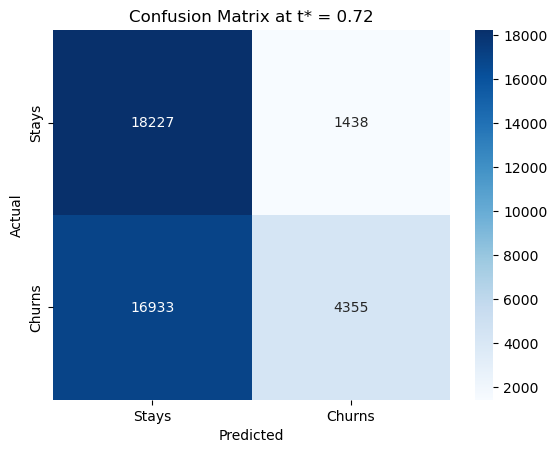

Precision at t*: 75.18%
Recall at t*: 20.46%


In [3]:
t_star = 0.72  # or import from config if you've stored it there

preds_t_star = (probs > t_star).astype(int)

cm = confusion_matrix(test_y, preds_t_star)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix at t* = {t_star}')
plt.show()

print(f'Precision at t*: {precision_score(test_y, preds_t_star):.2%}')
print(f'Recall at t*: {recall_score(test_y, preds_t_star):.2%}')

True positives (churners correctly targeted):  4,355
False positives (non-churners incorrectly targeted): 1,438
False negatives (churners missed): 16,933
True negatives (non-churners correctly left alone): 18,227

Revenue from true positives (retained at cost): £174,200
Cost of false positives (wasted interventions): £14,380
Lost revenue from false negatives (missed churners): £846,650


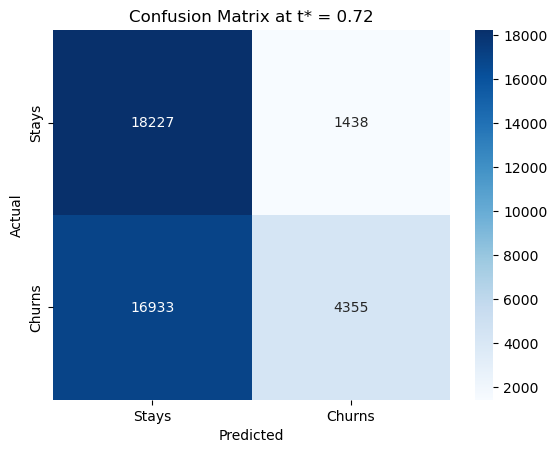

In [4]:
V= 50
C=10

t_star = 0.72

preds_t_star = (probs > t_star).astype(int)

cm = confusion_matrix(test_y, preds_t_star)
tn, fp, fn, tp = cm.ravel()

cost_fp = fp * C
revenue_tp = tp * (V - C)
lost_fn = fn * V

print(f'True positives (churners correctly targeted):  {tp:,}')
print(f'False positives (non-churners incorrectly targeted): {fp:,}')
print(f'False negatives (churners missed): {fn:,}')
print(f'True negatives (non-churners correctly left alone): {tn:,}')
print()
print(f'Revenue from true positives (retained at cost): £{revenue_tp:,.0f}')
print(f'Cost of false positives (wasted interventions): £{cost_fp:,.0f}')
print(f'Lost revenue from false negatives (missed churners): £{lost_fn:,.0f}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix at t* = {t_star}')
plt.show()

True positives (churners correctly targeted):  4,355
False positives (non-churners incorrectly targeted): 1,438
False negatives (churners missed): 16,933
True negatives (non-churners correctly left alone): 18,227

Revenue from successful interventions (true positives retained): £60,970
Cost of failed interventions (true positives not retained): £28,308
Cost of wasted interventions (false positives): £14,380
Lost revenue from missed churners (false negatives): £846,650


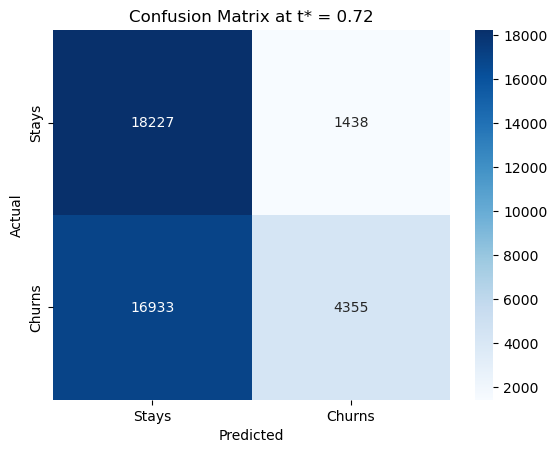

In [5]:
t_star = 0.72
p_retention = 0.35

preds_t_star = (probs > t_star).astype(int)

cm = confusion_matrix(test_y, preds_t_star)
tn, fp, fn, tp = cm.ravel()

revenue_tp = tp * p_retention * (V - C)
cost_failed_interventions = tp * (1 - p_retention) * C
cost_fp = fp * C
lost_fn = fn * V

print(f'True positives (churners correctly targeted):  {tp:,}')
print(f'False positives (non-churners incorrectly targeted): {fp:,}')
print(f'False negatives (churners missed): {fn:,}')
print(f'True negatives (non-churners correctly left alone): {tn:,}')
print()
print(f'Revenue from successful interventions (true positives retained): £{revenue_tp:,.0f}')
print(f'Cost of failed interventions (true positives not retained): £{cost_failed_interventions:,.0f}')
print(f'Cost of wasted interventions (false positives): £{cost_fp:,.0f}')
print(f'Lost revenue from missed churners (false negatives): £{lost_fn:,.0f}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix at t* = {t_star}')
plt.show()

Revenue from successful interventions (true positives retained): £60,970
Cost of false positives (non-churners unnecessarily offered discount): £14,380
Lost revenue from missed churners (false negatives): £237,062


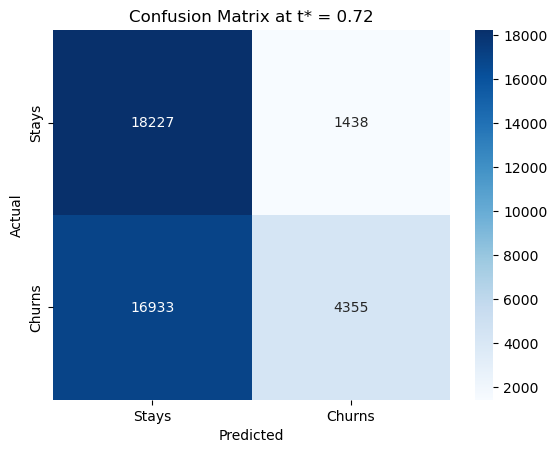

In [7]:
t_star = 0.72
p_retention = 0.35

preds_t_star = (probs > t_star).astype(int)

cm = confusion_matrix(test_y, preds_t_star)
tn, fp, fn, tp = cm.ravel()


est_from_intervention = tp * p_retention * (V - C)
est_wasted = fp * C
lost_fn = fn * (V-C) * p_retention

# print(f'True positives (churners correctly targeted):  {tp:,}')
# print(f'False positives (non-churners incorrectly targeted): {fp:,}')
# print(f'False negatives (churners missed): {fn:,}')
# print(f'True negatives (non-churners correctly left alone): {tn:,}')
# print()
print(f'Revenue from successful interventions (true positives retained): £{est_from_intervention:,.0f}')
print(f'Cost of false positives (non-churners unnecessarily offered discount): £{est_wasted:,.0f}')
print(f'Lost revenue from missed churners (false negatives): £{lost_fn:,.0f}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix at t* = {t_star}')
plt.show()

Revenue from successful interventions (true positives retained): £60,970
Cost of false positives (non-churners unnecessarily offered discount): £14,380
Net uplift from model: £46,590


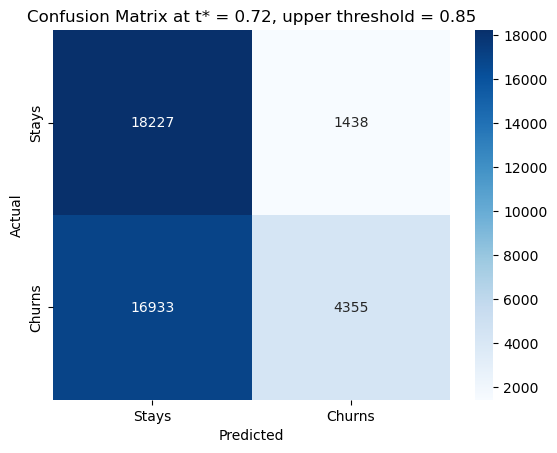

In [17]:
t_star = 0.72
UPPER_THRESHOLD = 0.85
p_retention = 0.35

preds_t_star = ((probs > t_star) & (probs < UPPER_THRESHOLD)).astype(int)

cm = confusion_matrix(test_y, preds_t_star)
tn, fp, fn, tp = cm.ravel()

est_from_intervention = tp * p_retention * (V - C)
est_wasted = fp * C
lost_fn = fn * (V-C) * p_retention
net_uplift = est_from_intervention - est_wasted

print(f'Revenue from successful interventions (true positives retained): £{est_from_intervention:,.0f}')
print(f'Cost of false positives (non-churners unnecessarily offered discount): £{est_wasted:,.0f}')
print(f'Net uplift from model: £{net_uplift:,.0f}')


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stays', 'Churns'],
            yticklabels=['Stays', 'Churns'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix at t* = {t_star}, upper threshold = {UPPER_THRESHOLD}')
plt.show()

The probability of churn is consistently overestimated by the model. This is consistent with the high recall of the model.